# 🪙 Gold Recovery Prediction — Full ML Pipeline
**Target**: `final.output.recovery` — the percentage of gold recovered in the flotation process.

**Pipeline Overview:**
1. Load & Inspect Data
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Imputation
4. Feature Engineering & Encoding
5. Model Training (XGBoost, LightGBM, Random Forest, Ridge, ElasticNet)
6. Model Comparison (R², RMSE, MAE)
7. Best Model Evaluation & Saving
8. Ideal Scenario Analysis (Maximising Gold Recovery)

---
## 1. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
TARGET = 'final.output.recovery'

# Plotting style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#333',
    'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'font.family': 'monospace',
})

GOLD = '#FFD700'
SILVER = '#C0C0C0'
TEAL = '#00CED1'
CORAL = '#FF6B6B'

print('✅ Imports successful')

✅ Imports successful


---
## 2. Load Dataset

In [5]:
# ─── Load data ───────────────────────────────────────────────────────────────
# Replace 'gold_recovery.csv' with your actual file path
CSV_PATH = 'gold_recovery_full.csv'  # <-- update path if needed

df = pd.read_csv(CSV_PATH)

# Parse datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df["date"].min()}  →  {df["date"].max()}')
print(f'Target column : {TARGET}')
df.head(3)

Dataset shape : (22716, 87)
Date range    : 2016-01-15 00:00:00  →  2018-08-18 10:59:59
Target column : final.output.recovery


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.output.concentrate_ag,primary_cleaner.output.concentrate_pb,primary_cleaner.output.concentrate_sol,primary_cleaner.output.concentrate_au,primary_cleaner.output.tail_ag,primary_cleaner.output.tail_pb,primary_cleaner.output.tail_sol,primary_cleaner.output.tail_au,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,...,rougher.state.floatbank10_e_level,rougher.state.floatbank10_f_air,rougher.state.floatbank10_f_level,secondary_cleaner.output.tail_ag,secondary_cleaner.output.tail_pb,secondary_cleaner.output.tail_sol,secondary_cleaner.output.tail_au,secondary_cleaner.state.floatbank2_a_air,secondary_cleaner.state.floatbank2_a_level,secondary_cleaner.state.floatbank2_b_air,secondary_cleaner.state.floatbank2_b_level,secondary_cleaner.state.floatbank3_a_air,secondary_cleaner.state.floatbank3_a_level,secondary_cleaner.state.floatbank3_b_air,secondary_cleaner.state.floatbank3_b_level,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.0554,9.8896,5.5073,42.1920,70.5412,10.4120,0.8954,16.9043,2.1431,127.0920,10.1283,7.2500,0.9888,8.5476,10.3896,19.5293,34.1744,14.9365,2.5349,7.4761,2.1067,1549.7758,-498.9121,1551.4342,...,-455.4630,1416.3550,-451.9396,14.5002,4.6948,8.7646,2.6062,25.8531,-498.5265,23.8937,-501.4063,23.9618,-495.2628,21.9404,-499.3410,14.0168,-502.4880,12.0999,-504.7159,9.9256,-498.3102,8.0797,-500.4710,14.1513,-605.8420
1,2016-01-15 01:00:00,6.0294,9.9689,5.2578,42.7016,69.2662,10.4627,0.9275,16.6345,2.2249,125.6292,10.2963,7.2500,1.0027,8.5587,10.4971,19.3691,34.1185,16.2505,3.0496,6.7339,2.3530,1576.1667,-500.9050,1575.9506,...,-450.8698,1399.7195,-450.1190,14.2655,4.5925,9.0015,2.4882,25.8805,-499.9897,23.8895,-500.3724,23.9706,-500.0855,22.0857,-499.4469,13.9923,-505.5033,11.9505,-501.3315,10.0392,-500.1700,7.9848,-500.5822,13.9984,-599.7872
2,2016-01-15 02:00:00,6.0559,10.2140,5.3838,42.6575,68.1164,10.5070,0.9537,16.2088,2.2579,123.8198,11.3163,7.2500,0.9913,8.6035,10.3545,19.1676,33.9695,16.4918,3.1247,6.4718,2.4168,1601.5562,-499.9978,1600.3867,...,-449.9376,1400.3167,-450.5271,14.1157,4.6248,8.8429,2.4582,26.0052,-499.9296,23.8867,-499.9519,23.9135,-499.4423,23.9577,-499.9020,14.0150,-502.5209,11.9128,-501.1334,10.0709,-500.1291,8.0139,-500.5176,14.0287,-601.4274


---
## 3. Basic Dataset Overview

In [6]:
print('=== DATA TYPES ===')
print(df.dtypes.value_counts())

print('\n=== MISSING VALUES (%) ===')
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(miss[miss > 0].head(20))

print('\n=== DESCRIPTIVE STATISTICS ===')
df.describe().T

=== DATA TYPES ===
float64           86
datetime64[us]     1
Name: count, dtype: int64

=== MISSING VALUES (%) ===
rougher.output.recovery                  13.7304
rougher.output.tail_ag                   12.0488
rougher.output.tail_au                   12.0444
rougher.output.tail_sol                  12.0444
rougher.input.floatbank11_xanthate        9.9357
secondary_cleaner.output.tail_sol         9.7508
final.output.recovery                     8.6415
rougher.calculation.au_pb_ratio           7.1624
primary_cleaner.input.sulfate             7.0831
primary_cleaner.input.depressant          6.8058
rougher.input.floatbank10_sulfate         5.7272
primary_cleaner.input.xanthate            5.0669
primary_cleaner.output.concentrate_sol    3.5129
rougher.input.floatbank11_sulfate         2.9847
rougher.state.floatbank10_e_air           2.7294
rougher.input.feed_rate                   2.4344
rougher.input.floatbank10_xanthate        2.0646
primary_cleaner.output.concentrate_pb     1.9722
rou

,count,mean,min,25%,50%,75%,max,std
date,22716,2017-05-02 05:29:59.105080,2016-01-15 00:00:00,2016-09-07 14:44:59,2017-05-02 05:29:59,2017-12-24 20:14:59,2018-08-18 10:59:59,NaN
final.output.concentrate_ag,22627.0000,4.7816,0.0000,4.0185,4.9537,5.8626,16.0019,2.0301
final.output.concentrate_pb,22629.0000,9.0953,0.0000,8.7502,9.9145,10.9298,17.0319,3.2308
final.output.concentrate_sol,22331.0000,8.6403,0.0000,7.1168,8.9088,10.7058,19.6157,3.7850
final.output.concentrate_au,22630.0000,40.0012,0.0000,42.3837,44.6534,46.1120,53.6114,13.3981
...,...,...,...,...,...,...,...,...
secondary_cleaner.state.floatbank5_a_level,22615.0000,-503.3233,-799.7411,-500.6287,-499.8652,-498.4894,-244.4836,72.9256
secondary_cleaner.state.floatbank5_b_air,22615.0000,11.6267,0.4271,8.0375,10.9898,14.0012,39.8462,5.7574
secondary_cleaner.state.floatbank5_b_level,22616.0000,-500.5215,-800.2582,-500.1679,-499.9520,-499.4924,-120.1909,78.9563
secondary_cleaner.state.floatbank6_a_air,22597.0000,17.9768,-0.0794,13.9684,18.0042,23.0097,54.8768,6.6362


In [7]:
# ─── Column categories ───────────────────────────────────────────────────────
non_feature_cols = ['date', TARGET]

# Identify leakage columns: other 'final.output.*' columns (they come after the target event)
leakage_cols = [c for c in df.columns if c.startswith('final.output.') and c != TARGET]
print('Leakage columns removed:', leakage_cols)

feature_cols = [c for c in df.columns if c not in non_feature_cols + leakage_cols]
print(f'\nTotal features : {len(feature_cols)}')

Leakage columns removed: ['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au']

Total features : 77


---
## 4. Exploratory Data Analysis (EDA)

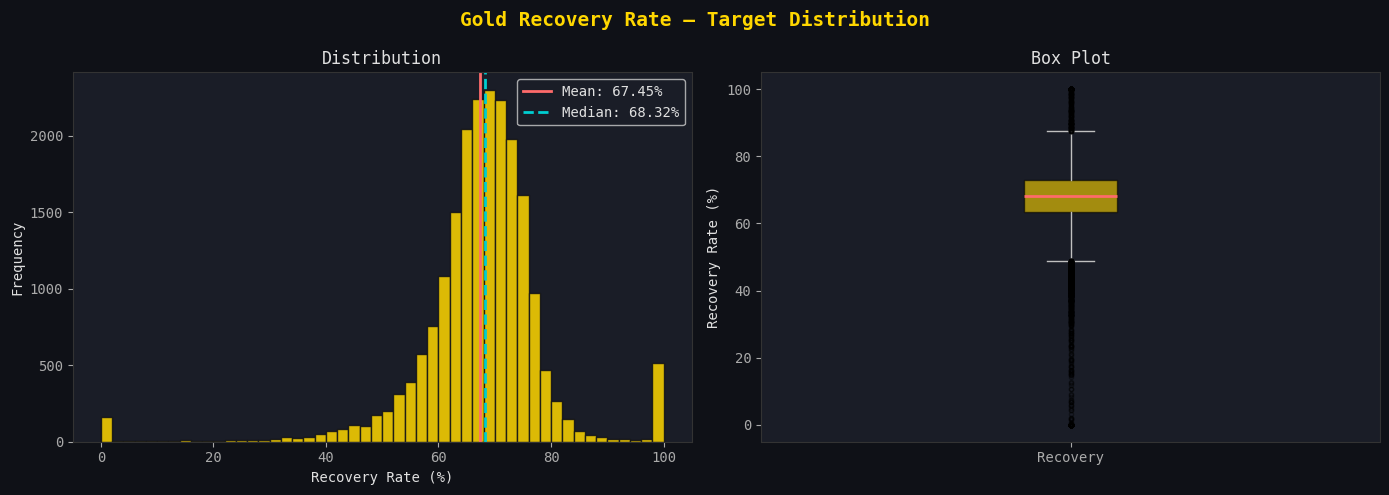

In [8]:
# ─── Target distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gold Recovery Rate — Target Distribution', color=GOLD, fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=50, color=GOLD, edgecolor='#0f1117', alpha=0.85)
axes[0].axvline(df[TARGET].mean(), color=CORAL, lw=2, label=f'Mean: {df[TARGET].mean():.2f}%')
axes[0].axvline(df[TARGET].median(), color=TEAL, lw=2, linestyle='--', label=f'Median: {df[TARGET].median():.2f}%')
axes[0].set_xlabel('Recovery Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_title('Distribution')

# Box plot
bp = axes[1].boxplot(df[TARGET].dropna(), patch_artist=True,
                     boxprops=dict(facecolor=GOLD, alpha=0.6),
                     medianprops=dict(color=CORAL, lw=2),
                     whiskerprops=dict(color=SILVER),
                     capprops=dict(color=SILVER),
                     flierprops=dict(marker='o', color=TEAL, alpha=0.4, markersize=3))
axes[1].set_ylabel('Recovery Rate (%)')
axes[1].set_title('Box Plot')
axes[1].set_xticklabels(['Recovery'])

plt.tight_layout()
plt.savefig('plot_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

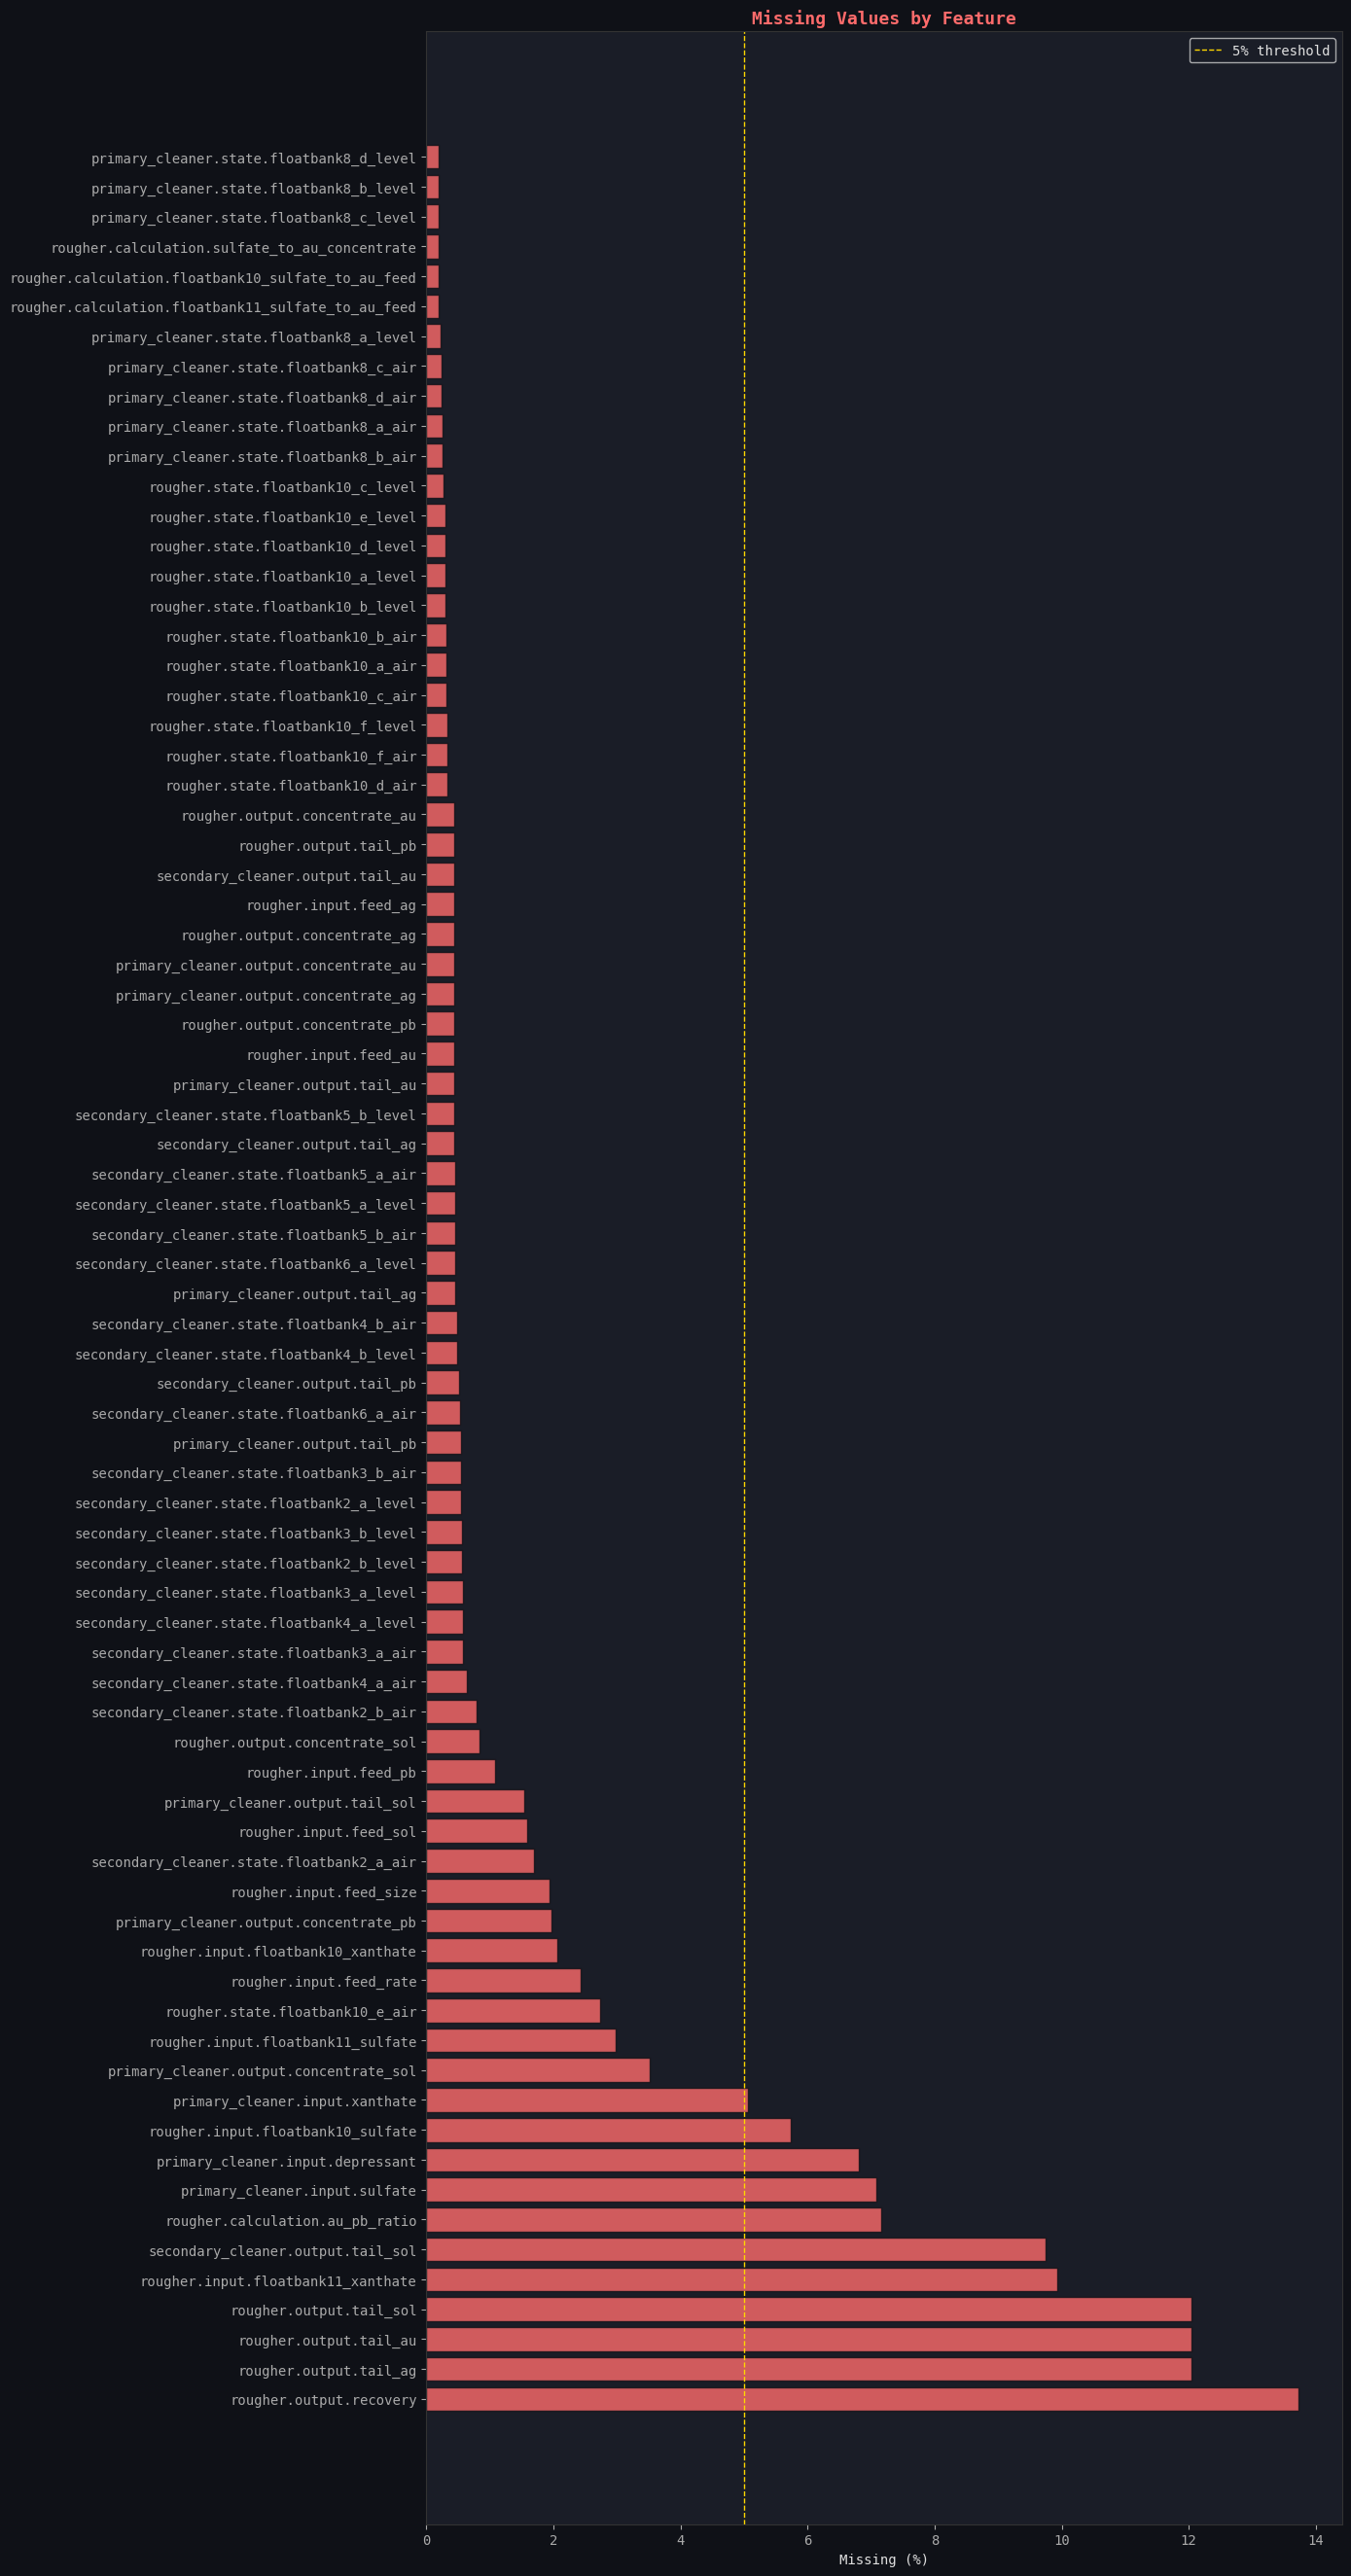

In [10]:
# ─── Missing value heatmap ────────────────────────────────────────────────────
miss_pct = (df[feature_cols].isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_df = miss_pct[miss_pct > 0]

if len(miss_df) > 0:
    fig, ax = plt.subplots(figsize=(14, max(4, len(miss_df) * 0.35)))
    bars = ax.barh(miss_df.index, miss_df.values, color=CORAL, alpha=0.8, edgecolor='#0f1117')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Feature', color=CORAL, fontsize=13, fontweight='bold')
    ax.axvline(5, color=GOLD, lw=1, linestyle='--', label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plot_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('✅ No missing values in feature columns!')

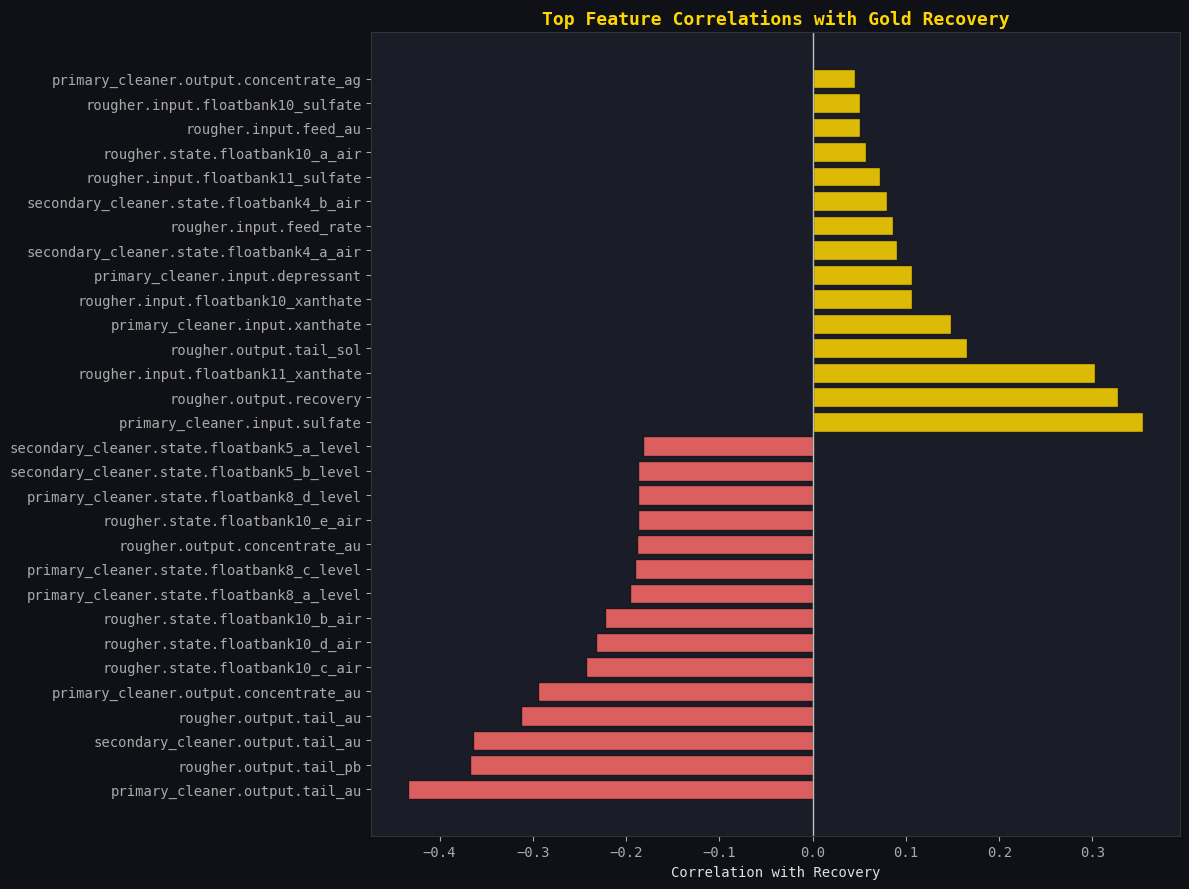

Top 10 positive correlators:
primary_cleaner.input.sulfate              0.3544
rougher.output.recovery                    0.3271
rougher.input.floatbank11_xanthate         0.3030
rougher.output.tail_sol                    0.1652
primary_cleaner.input.xanthate             0.1486
rougher.input.floatbank10_xanthate         0.1070
primary_cleaner.input.depressant           0.1068
secondary_cleaner.state.floatbank4_a_air   0.0904
rougher.input.feed_rate                    0.0862
secondary_cleaner.state.floatbank4_b_air   0.0795
Name: final.output.recovery, dtype: float64


In [11]:
# ─── Key feature correlations with target ─────────────────────────────────────
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

top_pos = corr_with_target.nlargest(15)
top_neg = corr_with_target.nsmallest(15)
top_corr = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(12, 9))
colors = [CORAL if v < 0 else GOLD for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, alpha=0.85, edgecolor='#0f1117')
ax.axvline(0, color=SILVER, lw=1)
ax.set_xlabel('Correlation with Recovery')
ax.set_title('Top Feature Correlations with Gold Recovery', color=GOLD, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 positive correlators:')
print(corr_with_target.nlargest(10))

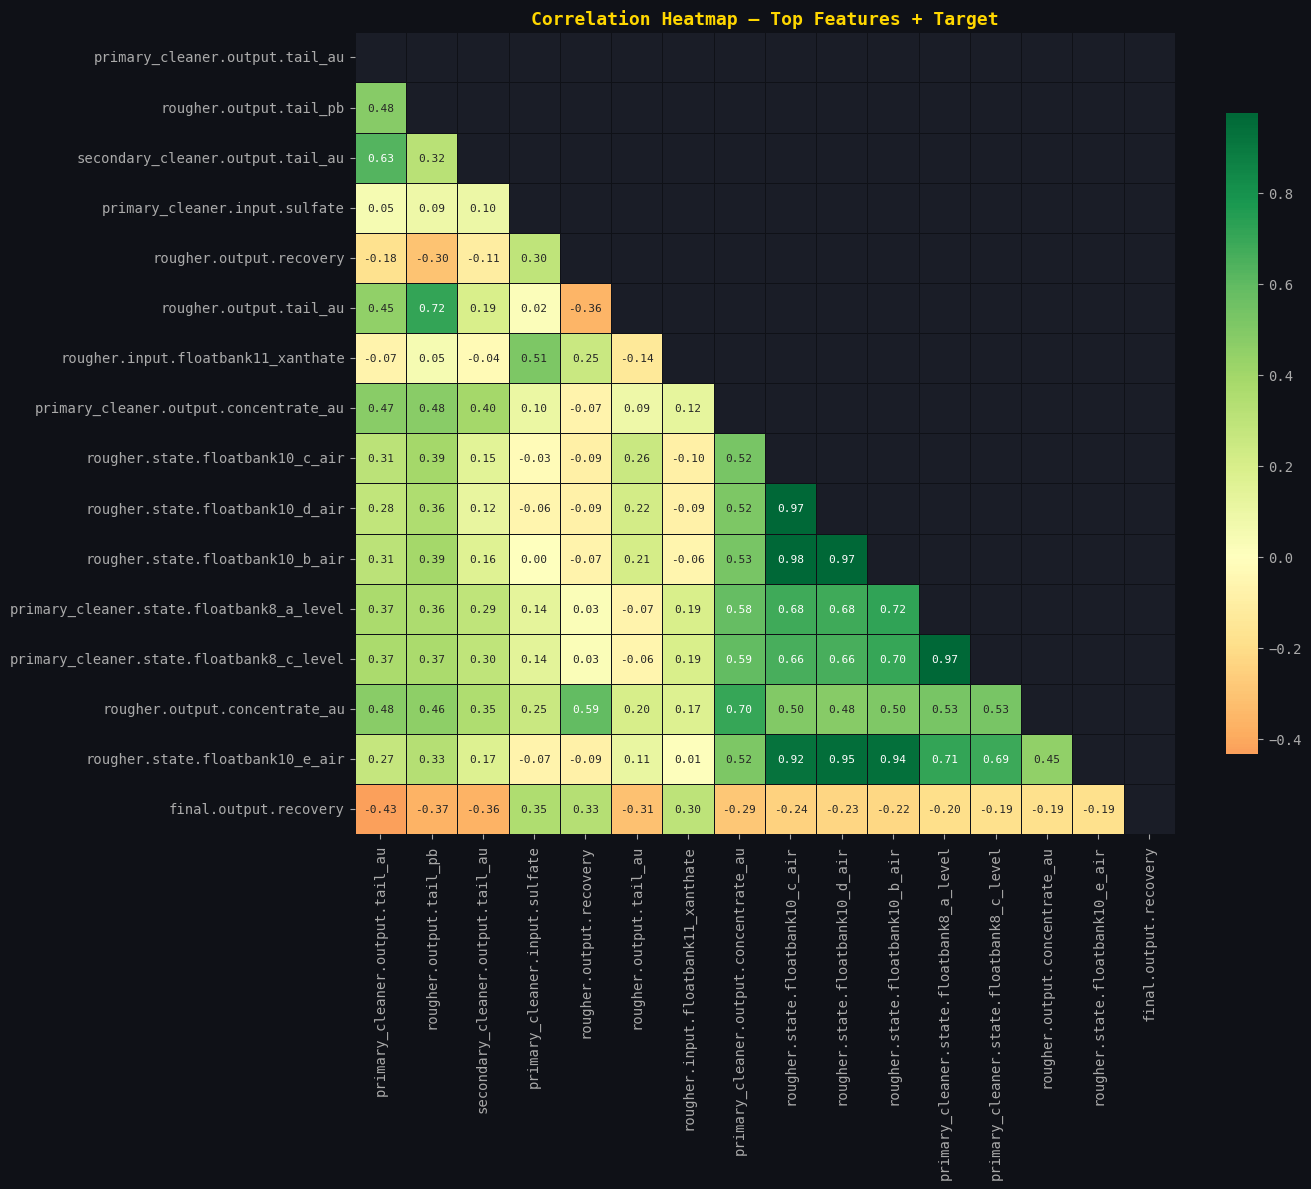

In [12]:
# ─── Correlation heatmap (key features) ──────────────────────────────────────
key_features = corr_with_target.abs().nlargest(15).index.tolist()
corr_matrix = df[key_features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, cbar_kws={'shrink': 0.8},
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top Features + Target', color=GOLD, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

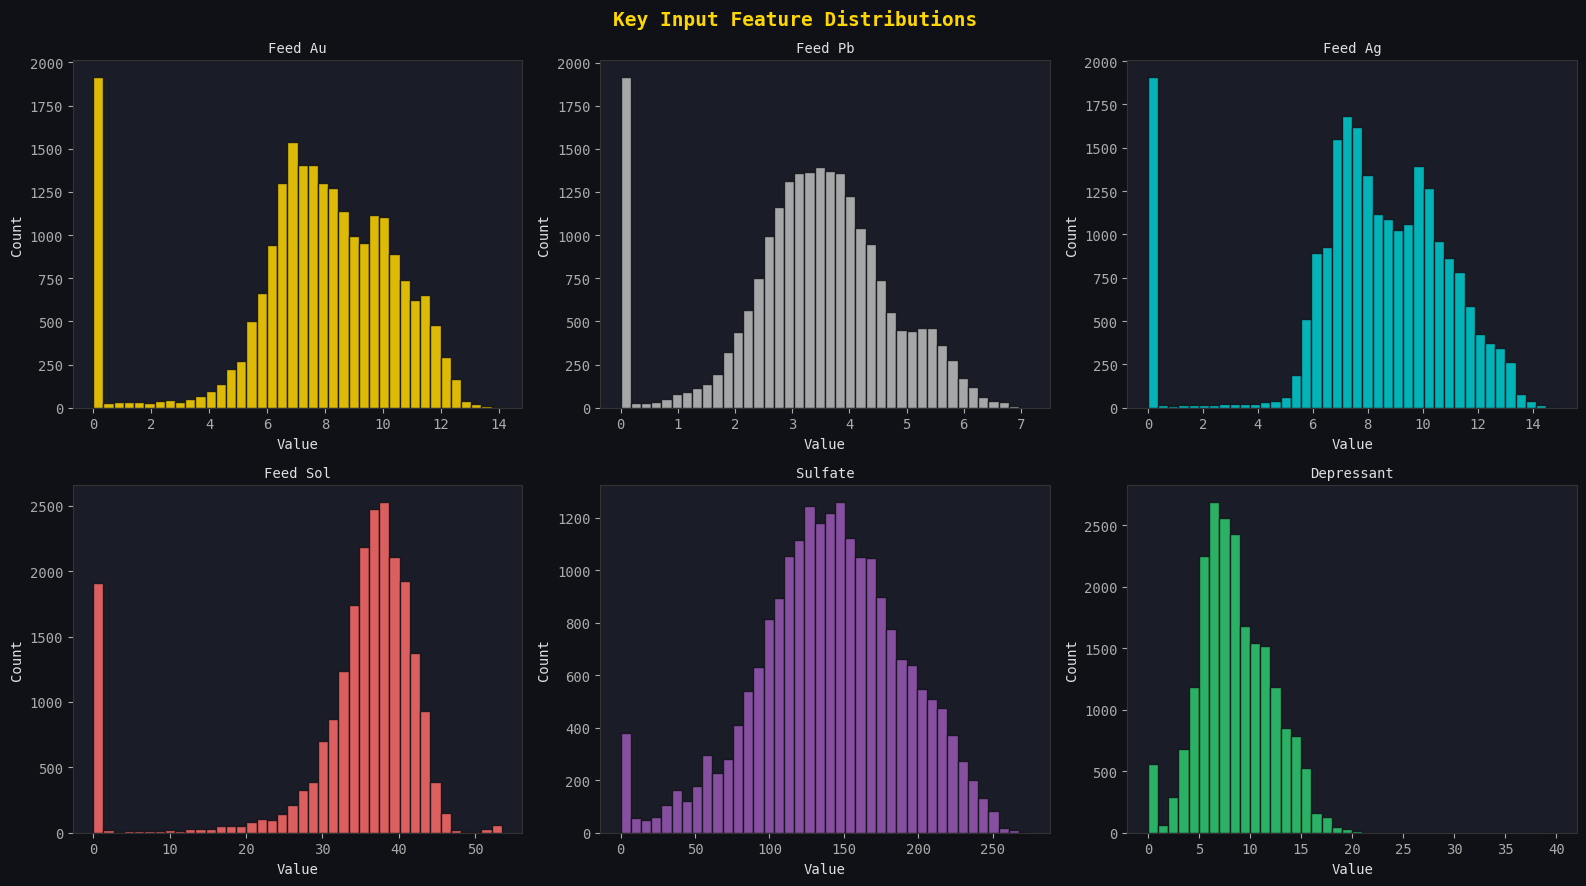

In [13]:
# ─── Key input distributions ─────────────────────────────────────────────────
input_features = [
    'rougher.input.feed_au',
    'rougher.input.feed_pb',
    'rougher.input.feed_ag',
    'rougher.input.feed_sol',
    'primary_cleaner.input.sulfate',
    'primary_cleaner.input.depressant',
]
input_features = [c for c in input_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors_cycle = [GOLD, SILVER, TEAL, CORAL, '#9B59B6', '#2ECC71']
for i, col in enumerate(input_features):
    axes[i].hist(df[col].dropna(), bins=40, color=colors_cycle[i], edgecolor='#0f1117', alpha=0.85)
    axes[i].set_title(col.split('.')[-1].replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
fig.suptitle('Key Input Feature Distributions', color=GOLD, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_input_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Data Cleaning & Feature Engineering

In [14]:
# ─── Prepare working DataFrame ────────────────────────────────────────────────
df_model = df[feature_cols + [TARGET]].copy()

# Drop rows where target is missing
df_model.dropna(subset=[TARGET], inplace=True)
print(f'Rows after dropping missing target: {len(df_model)}')

# ─── Add time features from index if date available ───────────────────────────
if df['date'].notna().any():
    df_model['hour']       = df.loc[df_model.index, 'date'].dt.hour
    df_model['day_of_week'] = df.loc[df_model.index, 'date'].dt.dayofweek
    df_model['month']      = df.loc[df_model.index, 'date'].dt.month
    print('✅ Time features added: hour, day_of_week, month')

Rows after dropping missing target: 20753
✅ Time features added: hour, day_of_week, month


In [15]:
# ─── Identify column types ────────────────────────────────────────────────────
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features : {len(numeric_features)}')
print(f'Categorical features: {len(cat_features)}')

# One-hot encode categorical features (if any)
if cat_features:
    X = pd.get_dummies(X, columns=cat_features, drop_first=True)
    print(f'Shape after OHE: {X.shape}')
    print('Encoded columns:', [c for c in X.columns if c not in numeric_features])
else:
    print('ℹ️  No categorical features — one-hot encoding not needed')

Numeric features : 80
Categorical features: 0
ℹ️  No categorical features — one-hot encoding not needed


In [16]:
# ─── Drop near-zero-variance columns ─────────────────────────────────────────
var = X.var()
low_var_cols = var[var < 1e-6].index.tolist()
print(f'Low-variance columns removed: {low_var_cols}')
X.drop(columns=low_var_cols, inplace=True)

# ─── KNN Imputation ────────────────────────────────────────────────────────────
print(f'Missing values before imputation: {X.isnull().sum().sum()}')
imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
print(f'Missing values after imputation : {X_imputed.isnull().sum().sum()}')

# Save imputer
joblib.dump(imputer, 'imputer.pkl')
print('✅ Imputer saved to imputer.pkl')

Low-variance columns removed: []
Missing values before imputation: 11698
Missing values after imputation : 0
✅ Imputer saved to imputer.pkl


In [17]:
# ─── Train / Test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Save feature names for app.py
feature_names = X_imputed.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print(f'Feature names saved ({len(feature_names)} features)')

Train: (16602, 80)  |  Test: (4151, 80)
Feature names saved (80 features)


---
## 6. Model Training & Comparison

In [18]:
# ─── Define models ────────────────────────────────────────────────────────────
models = {
    'Ridge Regression': Ridge(alpha=10),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12,
                                            min_samples_leaf=5, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=5,
                                                    learning_rate=0.05,
                                                    random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=RANDOM_STATE, n_jobs=-1,
                                  verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=RANDOM_STATE, n_jobs=-1,
                                    verbose=-1),
}

print('Models to train:', list(models.keys()))

Models to train: ['Ridge Regression', 'ElasticNet', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


In [19]:
# ─── Train, evaluate, compare ─────────────────────────────────────────────────
results = []

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    results.append({'Model': name, 'R²': r2, 'RMSE': rmse, 'MAE': mae})
    print(f'  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('\n=== MODEL COMPARISON ===')
print(results_df.to_string(index=False))

Training Ridge Regression...
  R²=0.4567  RMSE=8.4761  MAE=4.4123
Training ElasticNet...
  R²=0.4572  RMSE=8.4727  MAE=4.3963
Training Random Forest...
  R²=0.5337  RMSE=7.8531  MAE=3.6928
Training Gradient Boosting...
  R²=0.5754  RMSE=7.4931  MAE=3.2857
Training XGBoost...
  R²=0.6037  RMSE=7.2394  MAE=3.1015
Training LightGBM...
  R²=0.5930  RMSE=7.3368  MAE=3.1631

=== MODEL COMPARISON ===
            Model     R²   RMSE    MAE
          XGBoost 0.6037 7.2394 3.1015
         LightGBM 0.5930 7.3368 3.1631
Gradient Boosting 0.5754 7.4931 3.2857
    Random Forest 0.5337 7.8531 3.6928
       ElasticNet 0.4572 8.4727 4.3963
 Ridge Regression 0.4567 8.4761 4.4123


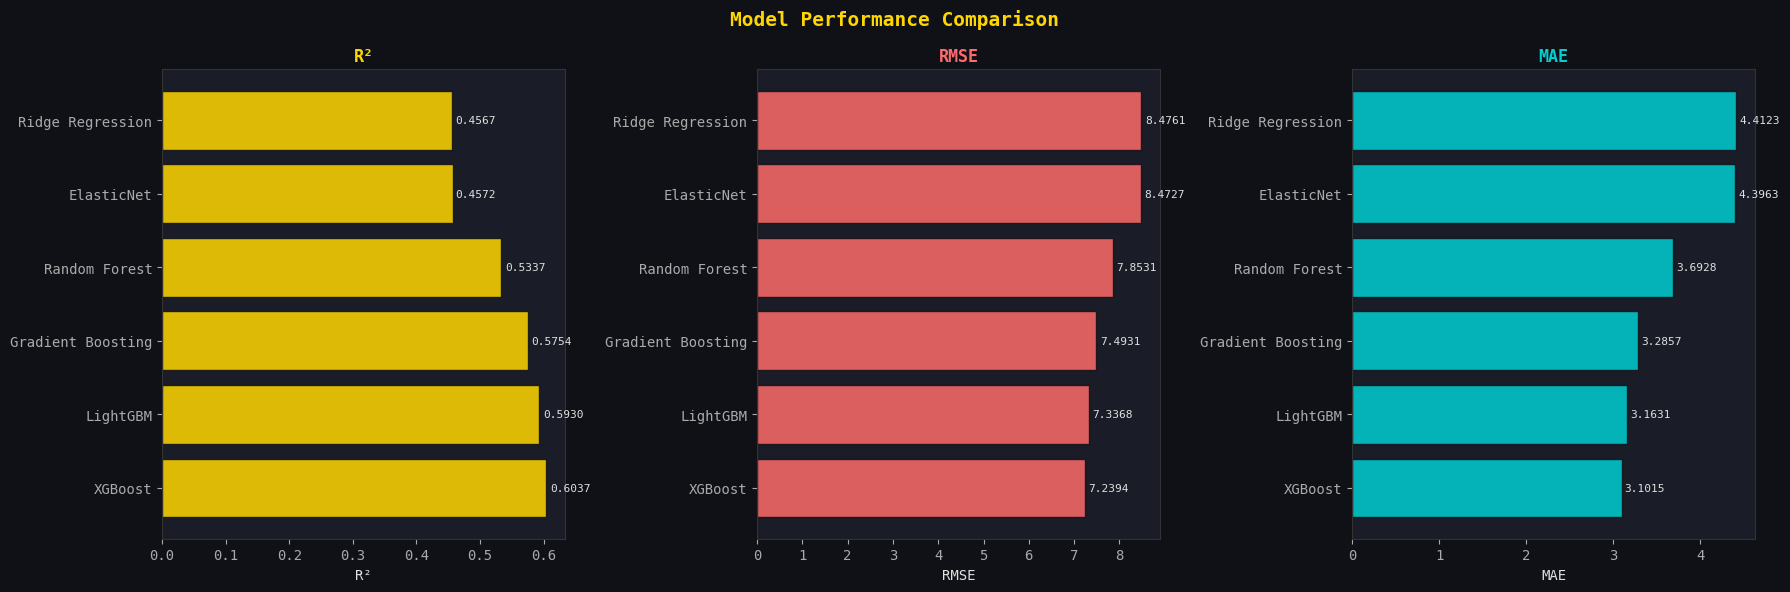

In [20]:
# ─── Model comparison bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', color=GOLD, fontsize=14, fontweight='bold')

metrics = ['R²', 'RMSE', 'MAE']
metric_colors = [GOLD, CORAL, TEAL]
model_names = results_df['Model'].tolist()

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = results_df[metric].tolist()
    bars = axes[i].barh(model_names, vals, color=color, alpha=0.85, edgecolor='#0f1117')
    axes[i].set_xlabel(metric)
    axes[i].set_title(metric, color=color, fontsize=12, fontweight='bold')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=8, color='#e0e0e0')

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Best Model — Detailed Evaluation

In [21]:
# ─── Select best model by R² ──────────────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f'🏆 Best Model: {best_model_name}')
print(f'   R²   = {results_df.iloc[0]["R²"]:.4f}')
print(f'   RMSE = {results_df.iloc[0]["RMSE"]:.4f}')
print(f'   MAE  = {results_df.iloc[0]["MAE"]:.4f}')

🏆 Best Model: XGBoost
   R²   = 0.6037
   RMSE = 7.2394
   MAE  = 3.1015


In [22]:
# ─── Cross-validation on best model ──────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_model, X_imputed, y, cv=kf, scoring='r2', n_jobs=-1)
print(f'5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold   : {cv_scores.round(4)}')

5-Fold CV R²: 0.6714 ± 0.0382
Per-fold   : [0.6113 0.6768 0.7316 0.6725 0.6648]


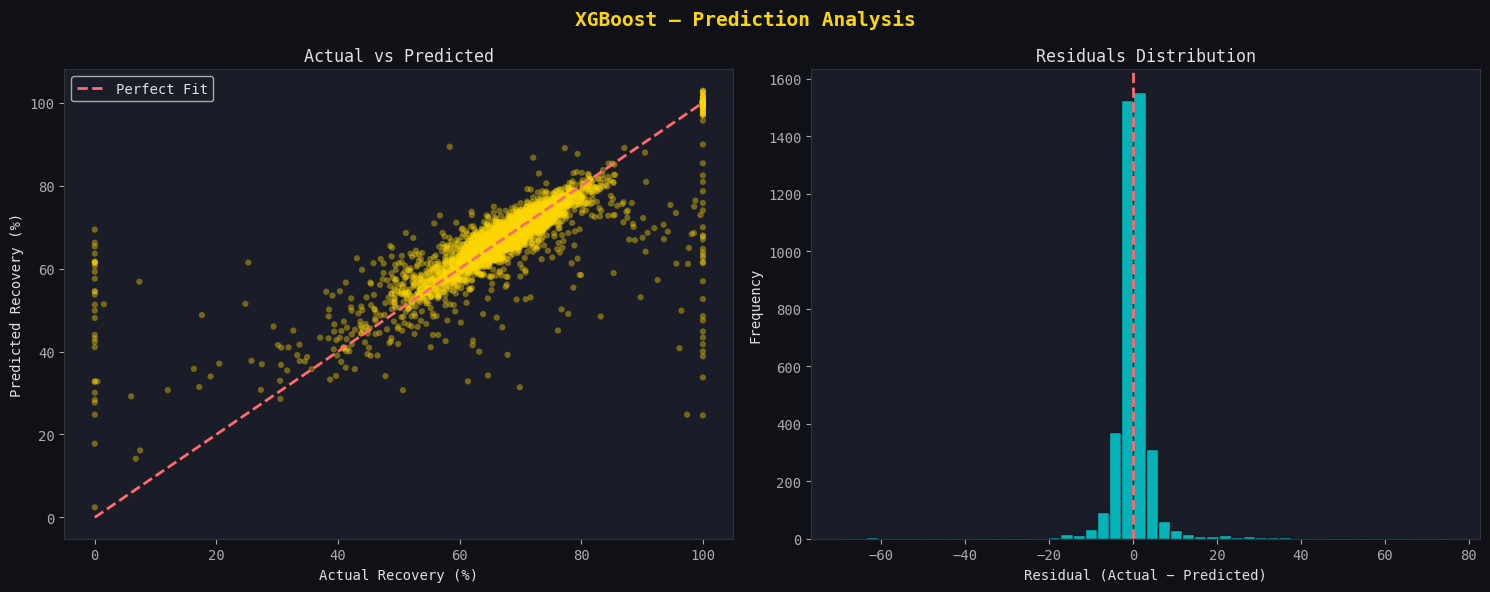

In [23]:
# ─── Actual vs Predicted ──────────────────────────────────────────────────────
y_pred_best = best_model.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'{best_model_name} — Prediction Analysis', color=GOLD, fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color=GOLD, s=20, edgecolors='none')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], color=CORAL, lw=2, linestyle='--', label='Perfect Fit')
axes[0].set_xlabel('Actual Recovery (%)')
axes[0].set_ylabel('Predicted Recovery (%)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals
axes[1].hist(residuals, bins=50, color=TEAL, edgecolor='#0f1117', alpha=0.85)
axes[1].axvline(0, color=CORAL, lw=2, linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

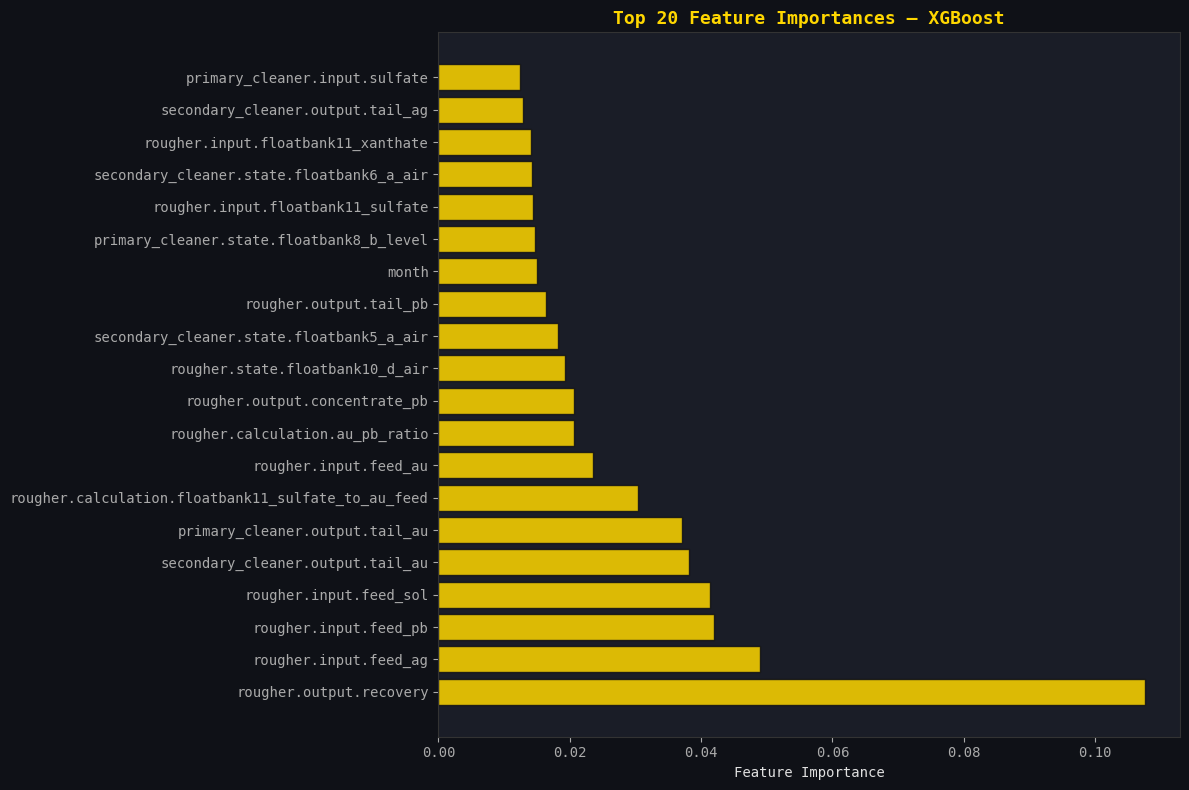

Top features saved to top_features.pkl


In [24]:
# ─── Feature Importance ───────────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_imputed.columns)
    top20 = importances.nlargest(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(top20.index, top20.values, color=GOLD, alpha=0.85, edgecolor='#0f1117')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Feature Importances — {best_model_name}',
                 color=GOLD, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Save top features for app
    top_features = top20.index.tolist()
    joblib.dump(top_features, 'top_features.pkl')
    print('Top features saved to top_features.pkl')
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(np.abs(best_model.coef_), index=X_imputed.columns)
    top20 = coefs.nlargest(20)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(top20.index, top20.values, color=GOLD, alpha=0.85)
    ax.set_title(f'Top 20 |Coefficients| — {best_model_name}',
                 color=GOLD, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 8. Save Final Model (≤ 50 MB)

In [25]:
# ─── Save model ───────────────────────────────────────────────────────────────
MODEL_PATH = 'gold_recovery_model.pkl'
joblib.dump(best_model, MODEL_PATH, compress=3)
size_mb = os.path.getsize(MODEL_PATH) / 1024**2
print(f'Model saved: {MODEL_PATH}  ({size_mb:.2f} MB)')

if size_mb > 50:
    print('⚠️  Model > 50 MB — reducing complexity...')
    if hasattr(best_model, 'n_estimators'):
        # Rebuild with fewer estimators
        params = best_model.get_params()
        params['n_estimators'] = max(50, params.get('n_estimators', 100) // 3)
        small_model = type(best_model)(**params)
        small_model.fit(X_train, y_train)
        joblib.dump(small_model, MODEL_PATH, compress=9)
        size_mb = os.path.getsize(MODEL_PATH) / 1024**2
        print(f'Reduced model saved: {size_mb:.2f} MB')
        best_model = small_model

assert size_mb <= 50, f'Model still > 50 MB ({size_mb:.2f} MB)!'
print(f'✅ Final model size: {size_mb:.2f} MB — within limit')

Model saved: gold_recovery_model.pkl  (0.39 MB)
✅ Final model size: 0.39 MB — within limit


In [26]:
# ─── Save metadata for Streamlit app ──────────────────────────────────────────
meta = {
    'best_model_name': best_model_name,
    'r2': float(results_df.iloc[0]['R²']),
    'rmse': float(results_df.iloc[0]['RMSE']),
    'mae': float(results_df.iloc[0]['MAE']),
    'n_features': len(feature_names),
    'n_train': len(X_train),
    'n_test': len(X_test),
    'n_total': len(df_model),
    'target': TARGET,
    'satisfactory_threshold': float(y.quantile(0.5)),  # median as threshold
    'high_recovery_threshold': float(y.quantile(0.75)),
    'target_mean': float(y.mean()),
    'target_std': float(y.std()),
    'target_min': float(y.min()),
    'target_max': float(y.max()),
    'results': results_df.to_dict(orient='records'),
    'feature_names': feature_names,
}
joblib.dump(meta, 'model_metadata.pkl')
print('✅ Metadata saved to model_metadata.pkl')

✅ Metadata saved to model_metadata.pkl


---
## 9. Ideal Scenario — Maximising Gold Recovery

In [27]:
# ─── Find top-10% recovery rows & analyse ideal conditions ────────────────────
p90 = y.quantile(0.90)
ideal_mask = y >= p90
df_ideal = X_imputed[ideal_mask]
df_normal = X_imputed[~ideal_mask]

print(f'High recovery rows (≥{p90:.2f}%): {ideal_mask.sum()}')
print(f'Normal rows                      : {(~ideal_mask).sum()}')

High recovery rows (≥76.87%): 2076
Normal rows                      : 18677


In [28]:
# ─── Compare mean values: ideal vs normal ─────────────────────────────────────
comparison = pd.DataFrame({
    'Ideal (Top 10%)': df_ideal.mean(),
    'Normal': df_normal.mean(),
})
comparison['Diff (Ideal - Normal)'] = comparison['Ideal (Top 10%)'] - comparison['Normal']
comparison['Diff %'] = (comparison['Diff (Ideal - Normal)'] / comparison['Normal'].abs() * 100).round(2)

# Top distinguishing features
top_diff = comparison['Diff %'].abs().nlargest(15)
print('=== Features Most Different in High-Recovery Scenarios ===')
print(comparison.loc[top_diff.index].to_string())

=== Features Most Different in High-Recovery Scenarios ===
                                                    Ideal (Top 10%)     Normal  Diff (Ideal - Normal)   Diff %
secondary_cleaner.output.tail_sol                            4.1675     6.9045                -2.7370 -39.6400
primary_cleaner.output.tail_au                               2.6215     4.0292                -1.4077 -34.9400
rougher.output.tail_pb                                       0.4352     0.6541                -0.2189 -33.4600
secondary_cleaner.output.tail_au                             2.9986     4.4538                -1.4552 -32.6700
rougher.calculation.floatbank11_sulfate_to_au_feed        2335.8399  3304.0022              -968.1622 -29.3000
rougher.calculation.floatbank10_sulfate_to_au_feed        2428.7640  3421.5945              -992.8305 -29.0200
rougher.calculation.sulfate_to_au_concentrate            32063.9636 42687.9979            -10624.0342 -24.8900
primary_cleaner.output.concentrate_au                

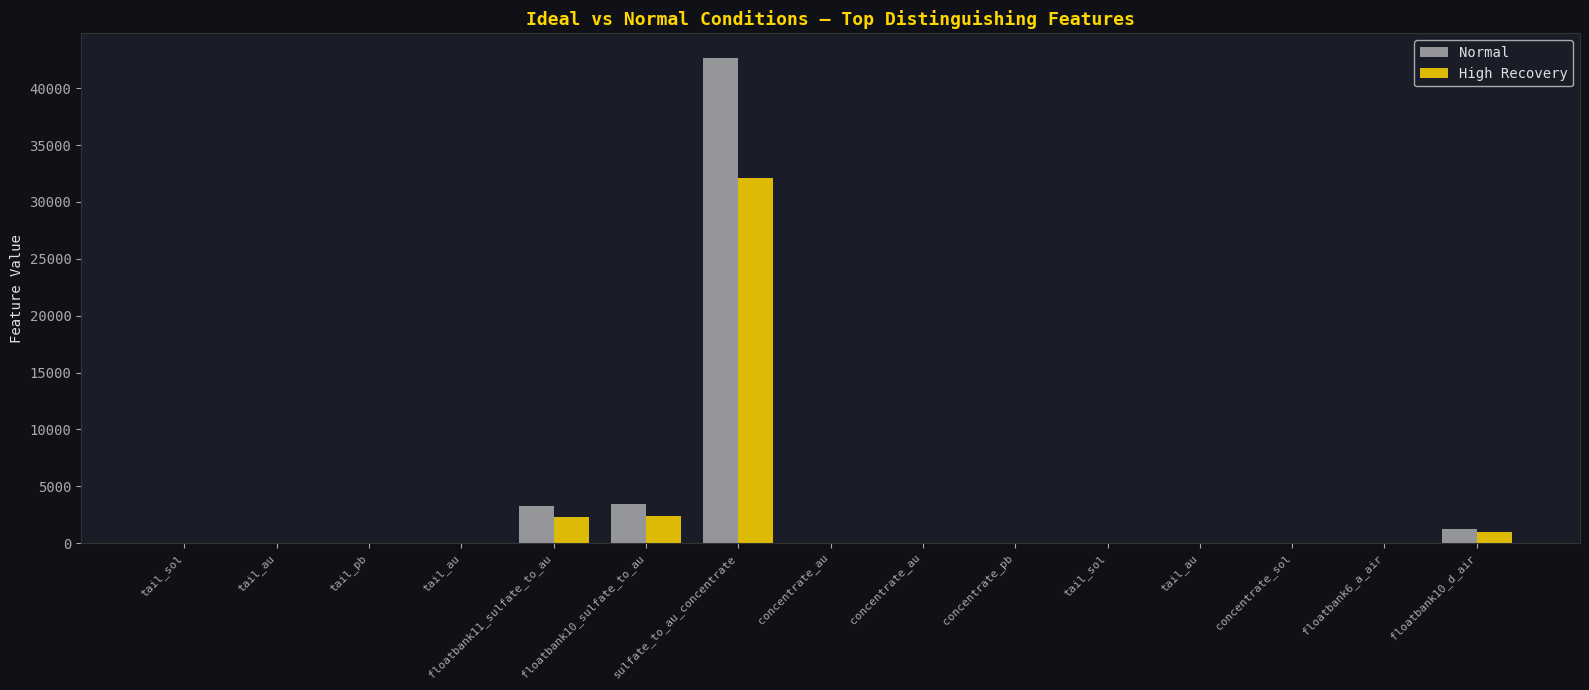

✅ Ideal scenario profile saved to ideal_profile.pkl


In [29]:
# ─── Ideal scenario visualisation ─────────────────────────────────────────────
top15_diff_idx = top_diff.index
ideal_vals   = comparison.loc[top15_diff_idx, 'Ideal (Top 10%)']
normal_vals  = comparison.loc[top15_diff_idx, 'Normal']

short_names = [c.split('.')[-1][:25] for c in top15_diff_idx]
x = np.arange(len(top15_diff_idx))
width = 0.38

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width/2, normal_vals,  width, label='Normal',        color=SILVER, alpha=0.75)
ax.bar(x + width/2, ideal_vals,   width, label='High Recovery',  color=GOLD,   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Feature Value')
ax.set_title('Ideal vs Normal Conditions — Top Distinguishing Features',
             color=GOLD, fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_ideal_scenario.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Save ideal scenario profile ──────────────────────────────────────────────
ideal_profile = df_ideal.mean().to_dict()
joblib.dump(ideal_profile, 'ideal_profile.pkl')
print('✅ Ideal scenario profile saved to ideal_profile.pkl')

In [30]:
# ─── Predict ideal scenario recovery ──────────────────────────────────────────
ideal_row = pd.DataFrame([ideal_profile])[feature_names].fillna(X_imputed.mean())
ideal_prediction = best_model.predict(ideal_row)[0]
print(f'🏅 Predicted recovery under IDEAL conditions: {ideal_prediction:.2f}%')
print(f'   (Actual top-10% mean: {y[ideal_mask].mean():.2f}%)')

🏅 Predicted recovery under IDEAL conditions: 70.26%
   (Actual top-10% mean: 85.31%)


---
## 10. Summary

In [31]:
print('=' * 60)
print('   GOLD RECOVERY PREDICTION — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset size     : {len(df_model)} rows, {len(feature_names)} features')
print(f'Target           : {TARGET}')
print(f'Target range     : {y.min():.2f}% — {y.max():.2f}%')
print(f'Target mean      : {y.mean():.2f}%')
print(f'Best model       : {best_model_name}')
print(f'  R²             : {results_df.iloc[0]["R²"]:.4f}')
print(f'  RMSE           : {results_df.iloc[0]["RMSE"]:.4f}')
print(f'  MAE            : {results_df.iloc[0]["MAE"]:.4f}')
print(f'Model size       : {os.path.getsize(MODEL_PATH)/1024**2:.2f} MB')
print(f'Ideal pred.      : {ideal_prediction:.2f}%')
print('=' * 60)
print('Files saved:')
for f in ['gold_recovery_model.pkl','imputer.pkl','feature_names.pkl',
           'model_metadata.pkl','ideal_profile.pkl','top_features.pkl']:
    if os.path.exists(f):
        print(f'  ✅ {f}  ({os.path.getsize(f)/1024:.1f} KB)')

   GOLD RECOVERY PREDICTION — FINAL SUMMARY
Dataset size     : 20753 rows, 80 features
Target           : final.output.recovery
Target range     : 0.00% — 100.00%
Target mean      : 67.45%
Best model       : XGBoost
  R²             : 0.6037
  RMSE           : 7.2394
  MAE            : 3.1015
Model size       : 0.39 MB
Ideal pred.      : 70.26%
Files saved:
  ✅ gold_recovery_model.pkl  (395.0 KB)
  ✅ imputer.pkl  (14595.7 KB)
  ✅ feature_names.pkl  (2.8 KB)
  ✅ model_metadata.pkl  (3.5 KB)
  ✅ ideal_profile.pkl  (3.5 KB)
  ✅ top_features.pkl  (0.6 KB)
